In [20]:
# RRCP (31/07/2026): Notebook de Estandarizacion de Variables
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Carga de Datos
df_partidos = pd.read_csv("../data/partidos_cebollitas_30072026.csv")
df_partidos.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [15]:
# Aplicar Normalizacion a tiros al arco (aprox. 0-15 tiros)
scaler_norm = MinMaxScaler()

df_partidos['tiros_arco_local_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_local']])
df_partidos['tiros_arco_visitante_norm'] = scaler_norm.fit_transform(df_partidos[['tiros_arco_visitante']])

# Ver resultados.
print(df_partidos[['tiros_arco_local', 'tiros_arco_local_norm']].head(6))
print(df_partidos[['tiros_arco_visitante', 'tiros_arco_visitante_norm']].head(6))


   tiros_arco_local  tiros_arco_local_norm
0                12               1.000000
1                12               1.000000
2                10               0.777778
3                 3               0.000000
4                 7               0.444444
5                 8               0.555556
   tiros_arco_visitante  tiros_arco_visitante_norm
0                     6                   0.333333
1                     3                   0.000000
2                     7                   0.444444
3                     3                   0.000000
4                    12                   1.000000
5                    11                   0.888889


In [23]:
# Aplicar Normalizacion de tiros al arco (aprox. 0-15 tiros)
scaler_norm = StandardScaler()

# fit: Calcula el minimo y el maximo de cada columna
# transform: Que aplica la formula anterior a cada dato.

# Ajusta el normalizador a los valores de la columna 'tiros_arco_local' y luego transforma (normaliza) toda la columna.
df_partidos['posesion_local_std'] = scaler_norm.fit_transform(df_partidos[['posesion_local (%)']])
# Ajusta el normalizador a los valores de la columna 'tiros_arco_visitante'y luego transforma (normaliza) toda la columna.
df_partidos['posesion_visitante_std'] = scaler_norm.fit_transform(df_partidos[['posesion_visitante (%)']])

# Ver resultados
print(df_partidos[['posesion_local (%)', 'posesion_local_std']])
print(df_partidos[['posesion_visitante (%)', 'posesion_visitante_std']])


    posesion_local (%)  posesion_local_std
0                   54            0.624415
1                   60            1.623479
2                   55            0.790926
3                   57            1.123947
4                   52            0.291394
..                 ...                 ...
95                  52            0.291394
96                  56            0.957436
97                  58            1.290457
98                  58            1.290457
99                  46           -0.707670

[100 rows x 2 columns]
    posesion_visitante (%)  posesion_visitante_std
0                       46               -0.624415
1                       40               -1.623479
2                       45               -0.790926
3                       43               -1.123947
4                       48               -0.291394
..                     ...                     ...
95                      48               -0.291394
96                      44               -0.957436
9

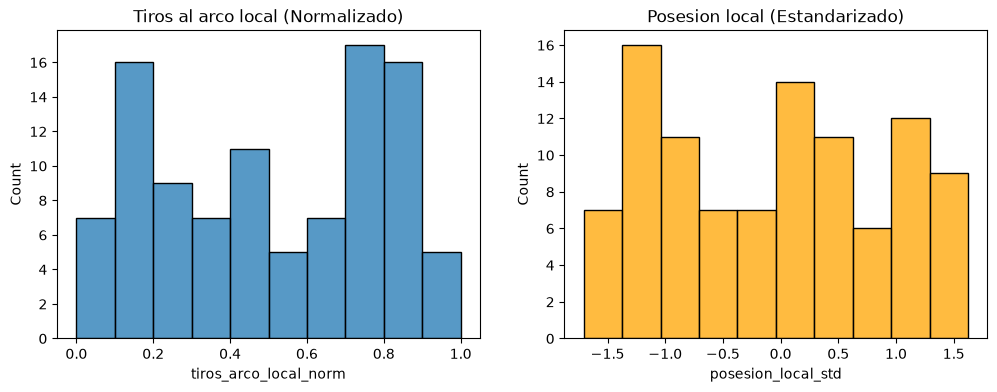

In [24]:
fig, ax = plt.subplots(1, 2, figsize = (12, 4))


# Visualizar tiros al arco (Normalizacion)
sns.histplot(df_partidos['tiros_arco_local_norm'], bins = 10, ax = ax[0])
ax[0].set_title("Tiros al arco local (Normalizado)")

# Visualizar posesion local (Estandarizado)
sns.histplot(df_partidos['posesion_local_std'], bins = 10, ax=ax[1], color = 'orange')
ax[1].set_title("Posesion local (Estandarizado)")

plt.show()